Step 1: Imoporting required packages(libraries)

In [ ]:
pip install numpy 
pip install pandas
pip install seaborn
pip install matplotlib.pyplot


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")


Step 2: Import the CSV data as Pandas Dataframe

In [58]:
df=pd.read_csv("D:\mlproject\data\Stud.csv")


Show top 5 records 

In [ ]:
df.head()

Shape of the dataset

In [6]:
df.shape

(1000, 8)

Dataset information 

In [ ]:
df.info

Step 3: Datachecks to perform
Cehck missing values 
check duplicated values 
check datatype 
Check the number of unique vaues of each column
Check the statistics of dataset 
Check various categories present in different catagorical columns

3.1: Check missing values 

In [ ]:
df.isna().sum()

there are no missing values in the dataset 

3.2: Check duplicate values 

In [ ]:
df.duplicated().sum()


There are no dunpilcate values in the dataset 

In [ ]:
3.3:Check datatypes 

In [ ]:
df.info()

3.4: checking the number of unique values of each column

In [ ]:
df.nunique()

3.5: Check the statistics of the dataset 

In [ ]:
df.describe()

Insight
From the above description all means are very close to each other, between 66 and 68.0
all standard deviations are also close from 14.6 to 15.195
minimum score for maths is 0 while minimum score for writing is 10 and reading might higher as 17.

3.7: Exploring Data

In [64]:
print("Categories in 'gender' variable:   ",end="   ")
print(df['gender'].unique())

Categories in 'gender' variable:      ['female' 'male']


In [25]:
print ("Categories in 'race/ethnicity' variable: ",end=" ")
print(df['race/ethnicity'].unique())

Categories in 'race/ethnicity' variable:  ['group B' 'group C' 'group A' 'group D' 'group E']


In [26]:
print("Categories in 'parental level of education' variable: ",end="")
print(df['parental level of education'].unique())

Categories in 'parental level of education' variable: ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']


In [27]:
print("Categories in 'lunch' variable: ",end="")
print(df['lunch'].unique())

Categories in 'lunch' variable: ['standard' 'free/reduced']


In [29]:
print("Categories in 'test preparation course' variable: ",end="")
print(df['test preparation course'].unique())

Categories in 'test preparation course' variable: ['none' 'completed']


In [ ]:
print("Categories in 'math score' variable: ",end="")
print(df['math score'].unique())

In [ ]:
print("Categories in ' reading score' variable: ",end="")
print(df['reading score'].unique())

In [ ]:
print("Categories in 'writing score' variable: ",end="")
print(df['writing score'].unique())

In [ ]:
#define numerical and catagorical data 
Numeric_features=[feature for feature in df.columns if df[feature].dtype!='0']
Catagorical_features=[feature for feature in df.columns if df[feature].dtype=='0']
#print the columns 
print('we have {} numerical features : {}'.format(len(Numeric_features),Numeric_features))
print('we have {} catagorical features: {}'.format(len(Catagorical_features),Catagorical_features))

3.8:  Feature Engineering: Adding columns for "Total score" and "Average"

In [ ]:
df['Total score']=df['math score']+df['reading score']+df['writing score']
df['Average']=df['Total score']/3
df.head(1)

In [ ]:
reading_full=df[df['reading score']==100]['Average'].count()
print(reading_full)
writing_full=df[df['writing score']==100]['Average'].count()
print(writing_full)
math_full=df[df['math score']==100]['Average'].count()
print(math_full)
print(f'Number of Students with full marks in reading score:{reading_full}')
print(f'Number of Students with full marks in writing score:{writing_full}')
print(f'Number of Students with full marks in maths:{math_full}')

In [ ]:
reading_less_20 = df[df['reading score']<=20]['Average'].count()
print(f'Number of students with less than 20 marks in reading:{reading_less_20}')
writing_less_20 = df[df['writing score']<=20]['Average'].count()
print(f'Number of students with less than 20 marks in writing:{writing_less_20}')
maths_less_20 = df[df['math score']<=20]['Average'].count()
print(f'Number of students with less than 20 marks in maths:{maths_less_20}')

Insigts
Students have performed worst in maths
Students have performmed well in reading score 

4: Data Visualization

4.1 visualize average score distribution to make some conclusions
Histogram
Kernel Distibution function(KDE)

4.1.1 Histogram and KDE

In [ ]:
fig, axs= plt.subplots(1,2,figsize=(10,5))
plt.subplot(121)
sns.histplot(data=df, x='Average',bins=30,kde=True,color='g')
plt.subplot(122)
sns.histplot(data=df,x='Average',bins=30,kde=True,hue='parental level of education')
plt.show()

In [ ]:
fig, axs= plt.subplots(1,2,figsize=(10,6))
plt.subplot(121)
sns.histplot(data=df, x='Average',bins=30,kde=True,color='g')
plt.subplot(122)
sns.histplot(data=df,x='Average',bins=30,kde=True,hue='gender')
plt.show()

Insights
Female students performs well as compared to male students

visualizatiion of total score based on the gender

In [ ]:
df.dtypes

In [ ]:
fig, axs= plt.subplots(1,2,figsize=(14,7))
plt.subplot(121)
sns.histplot(data=df, x='Total score',bins=30,kde=True,color='g')
plt.subplot(122)
sns.histplot(data=df,x='Total score',bins=30,kde=True,hue='test preparation course')
plt.show()

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(25,6))

sns.histplot(data=df, x='Average', bins=30, kde=True, hue='lunch', ax=axs[0])

sns.histplot(data=df[df.gender=='female'], x='Total score', bins=30, kde=True, hue='lunch',color='g', ax=axs[1])

sns.histplot(data=df[df.gender=='male'], x='Total score', bins=30, kde=True, color='g', hue='lunch', ax=axs[2])

plt.show()

Insights:
Standard lunch helps to peform well in exams 
standard lunch helps to improve well in exams either its female or male 

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(25,6))

sns.histplot(data=df, x='Average', bins=30, kde=True, hue='parental level of education', ax=axs[0])

sns.histplot(data=df[df.gender=='female'], x='Total score', bins=30, kde=True, hue='parental level of education',color='g', ax=axs[1])

sns.histplot(data=df[df.gender=='male'], x='Total score', bins=30, kde=True, color='g', hue='parental level of education', ax=axs[2])

plt.show()

Correlation
How two values move together
positive correlation: If one value goes up other also goes up
Negative correlation: If one value goes down , other goes up
Zero correlation: No effect

In [ ]:
# Correlation between numeric columns
correlation = df[['math score', 'reading score', 'writing score', 'Total score', 'Average']].corr()
print(correlation)

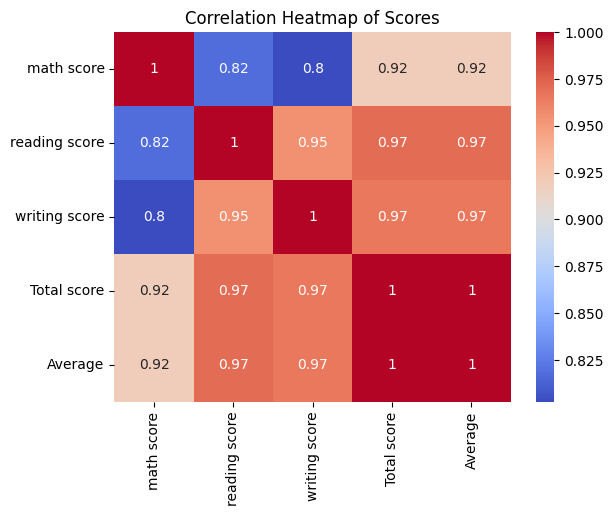

In [134]:
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap of Scores")
plt.show()

Red = Strong positive correlation (closer to 1)
Blue = Weaker correlation (closer to 0, but here all are strong)
Color scale is on the right → from ~0.82 (blue) to 1 (red)

Scatter plot 

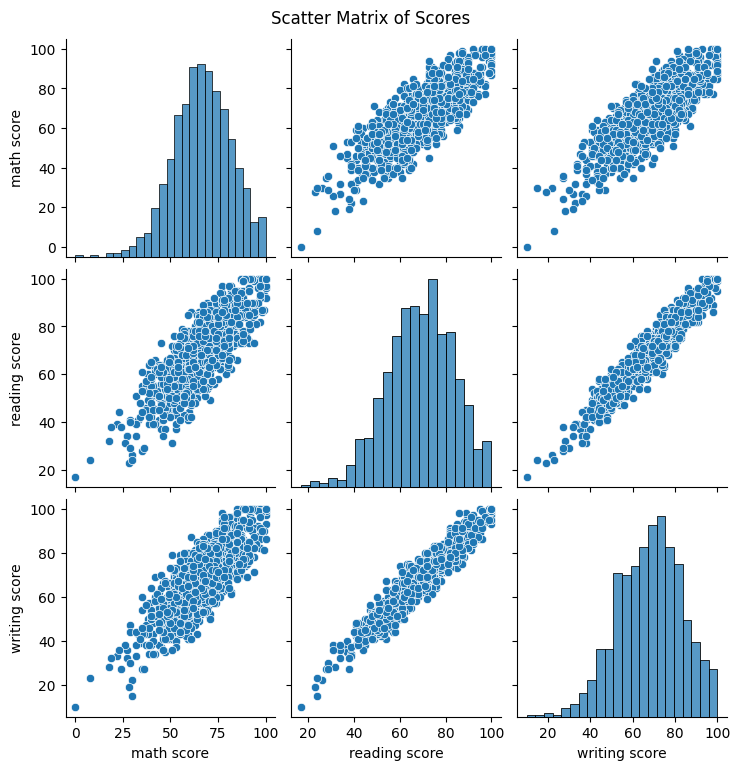

In [135]:
score_cols = ['math score', 'reading score', 'writing score']

# Pairplot (scatter matrix)
sns.pairplot(df[score_cols])
plt.suptitle("Scatter Matrix of Scores", y=1.02)
plt.show()